# 01. EDA — 데이터 구조 파악

2019-10, 2019-11 두 달치 데이터로 다음을 확인한다.
1. 원본 구조 미리보기
2. 분석 대상 로드 (메모리 절약을 위해 필요한 컬럼만)
3. 기간 확인 (파일명과 실제 데이터 기간이 일치하는지)
4. 이벤트 타입(view/cart/remove_from_cart/purchase) 분포
5. 결측치 확인

유저·세션 단위 통계(활동 빈도 등)는 다음 단계에서 이어서 진행한다.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import config
from src import load

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

plt.rcParams["font.family"] = "AppleGothic" # 맥북 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 1. 원본 구조 미리보기

전체를 불러오지 않고 상위 5행만 읽어 컬럼 구성과 원본 dtype을 눈으로 확인한다.

In [2]:
preview = pd.read_csv(config.RAW_PATHS[0], nrows=5)
print(preview.dtypes)
preview

event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## 2. 분석 대상 로드

2019-10, 2019-11 두 파일을 각각 로드한다. `product_id, category_id, user_session`은
기간·이벤트분포·결측치 확인에 필요 없으므로 제외하고 6개 컬럼만 읽어 메모리를 아낀다.
(세션 단위 분석은 03_funnel 단계에서 별도로 로드)

In [3]:
usecols = ["event_time", "event_type", "category_code", "brand", "price", "user_id"]

months = {
    "2019-10": config.RAW_PATHS[0],
    "2019-11": config.RAW_PATHS[1],
}

dfs = {name: load.load_month(path, usecols=usecols) for name, path in months.items()}

for name, df in dfs.items():
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"{name}: {df.shape[0]:,} rows, {mem_mb:,.1f} MB")

2019-10: 42,448,764 rows, 1,019.0 MB
2019-11: 67,501,979 rows, 1,687.8 MB


## 3. 기간 확인

각 파일의 `event_time` 최소/최대값을 확인해 파일명이 가리키는 월과 실제 데이터 기간이
일치하는지 검증한다.

In [4]:
for name, df in dfs.items():
    print(f"{name}: {df['event_time'].min()} ~ {df['event_time'].max()}")

2019-10: 2019-10-01 00:00:00+00:00 ~ 2019-10-31 23:59:59+00:00
2019-11: 2019-11-01 00:00:00+00:00 ~ 2019-11-30 23:59:59+00:00


## 4. 이벤트 타입 분포 & 결측치 확인

두 달을 합쳐서 이벤트 타입별 개수·비율을 확인하고, 컬럼별 결측치 비율을 확인한다.

In [5]:
combined = pd.concat(dfs.values(), ignore_index=True)
print(f"combined: {combined.shape[0]:,} rows")

event_counts = combined["event_type"].value_counts()
event_ratio = combined["event_type"].value_counts(normalize=True)

event_summary = pd.DataFrame({"count": event_counts, "ratio": event_ratio})
event_summary

combined: 109,950,743 rows


,count,ratio
event_type,,
view,104335509,0.948930
cart,3955446,0.035975
purchase,1659788,0.015096


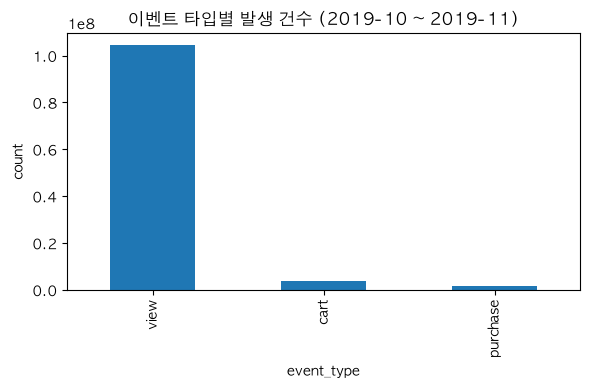

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
event_counts.plot(kind="bar", ax=ax)
ax.set_title("이벤트 타입별 발생 건수 (2019-10 ~ 2019-11)")
ax.set_xlabel("event_type")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_event_type_distribution.png", dpi=150)
plt.show()

In [7]:
missing_ratio = combined.isna().mean().sort_values(ascending=False)
missing_ratio.to_frame("missing_ratio")

,missing_ratio
category_code,0.322088
brand,0.139528
event_time,0.000000
event_type,0.000000
price,0.000000
user_id,0.000000


## 5. 유저·세션 단위 통계

이탈 정의(N일 무활동)의 근거 자료로 쓰기 위해 유저 활동 패턴을 확인한다.
- `event_time, user_id, user_session` 3개 컬럼만 로드 (이번엔 event_type/가격/카테고리 불필요)
- `user_session`은 UUID라 카디널리티가 높아 메모리를 더 쓸 수 있으므로 로드 직후 실측 확인

In [8]:
usecols_5 = ["event_time", "user_id", "user_session"]

dfs_5 = {name: load.load_month(path, usecols=usecols_5) for name, path in months.items()}
activity = pd.concat(dfs_5.values(), ignore_index=True)
del dfs_5

mem_mb = activity.memory_usage(deep=True).sum() / 1e6
print(f"activity: {activity.shape[0]:,} rows, {mem_mb:,.1f} MB")

activity: 109,950,743 rows, 6,597.1 MB


### 5-1. 유저당 이벤트 수

유저 한 명이 2달 동안 평균 몇 번 활동(view/cart/purchase 합계)하는지 확인한다.

In [9]:
events_per_user = activity.groupby("user_id").size()
print(f"유저 수: {events_per_user.shape[0]:,}")
events_per_user.describe()

유저 수: 5,316,649


count    5.316649e+06
mean     2.068046e+01
std      5.391672e+01
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.800000e+01
max      2.292900e+04
dtype: float64

### 5-2. 유저당 세션 수

2달 동안 유저 한 명이 몇 번이나 재방문(세션)했는지 확인한다.

In [10]:
sessions_per_user = activity.groupby("user_id")["user_session"].nunique()
sessions_per_user.describe()

count    5.316649e+06
mean     4.329342e+00
std      1.638291e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      2.254200e+04
Name: user_session, dtype: float64

### 5-3. 세션당 이벤트 수

한 번 방문(세션)했을 때 몇 개의 이벤트(주로 상품 조회)가 발생하는지 확인한다.

In [11]:
events_per_session = activity.groupby("user_session").size()
events_per_session.describe()

count    2.301665e+07
mean     4.777008e+00
std      7.453235e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      4.128000e+03
dtype: float64

### 5-4. 재방문 간격 (이탈 정의 핵심 참고자료)

같은 유저의 연속된 활동일(day) 사이 간격을 일(day) 단위로 계산해 분포를 본다.
이 분포가 04_churn_features에서 "N일 무활동 = 이탈" 기준을 정하는 핵심 근거가 된다.

In [12]:
activity_days = activity[["user_id", "event_time"]].copy()
activity_days["day"] = activity_days["event_time"].dt.floor("D")
activity_days = activity_days.drop_duplicates(subset=["user_id", "day"])[["user_id", "day"]]
activity_days = activity_days.sort_values(["user_id", "day"])

activity_days["gap_days"] = activity_days.groupby("user_id")["day"].diff().dt.days
revisit_gaps = activity_days["gap_days"].dropna()

print(f"재방문(2회 이상 활동) 발생 건수: {revisit_gaps.shape[0]:,}")
revisit_gaps.describe()

재방문(2회 이상 활동) 발생 건수: 9,778,495


count    9.778495e+06
mean     6.478585e+00
std      8.186194e+00
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      8.000000e+00
max      6.000000e+01
Name: gap_days, dtype: float64

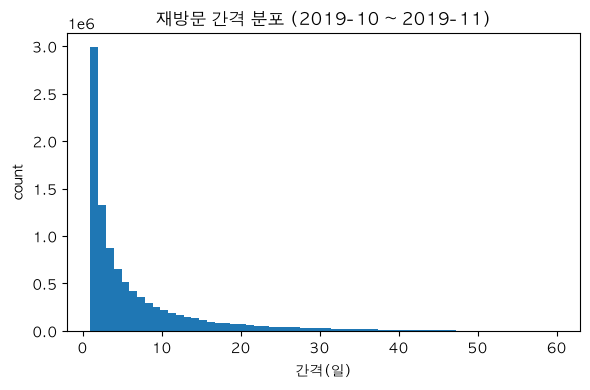

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
revisit_gaps.plot(kind="hist", bins=60, ax=ax)
ax.set_title("재방문 간격 분포 (2019-10 ~ 2019-11)")
ax.set_xlabel("간격(일)")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_revisit_gap_distribution.png", dpi=150)
plt.show()